# Segmentation clients et prédiction du churn (BankChurners)

Ce notebook reprend le pipeline de `train.py` :
1. Préparation des données
2. CAH sur les variables
3. ACP (PCA)
4. CAH sur les individus
5. Profilage des segments et croisement au churn
6. KNN — prédiction supervisée du churn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    silhouette_score,
)

RANDOM_STATE = 42

## Étape 1 — Préparation

In [2]:
print("=" * 60)
print("ÉTAPE 1 — PRÉPARATION")
print("=" * 60)

FIGURES_DIR = "figures"
DATA_DIR = "data"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

df = pd.read_csv(f"{DATA_DIR}/BankChurners.csv")

# Vérification qualité des données : valeurs manquantes et doublons
missing = df.isna().sum()
missing = missing[missing > 0]
n_duplicated_rows = df.duplicated().sum()
n_duplicated_ids = df["CLIENTNUM"].duplicated().sum()

print(f"Dimensions brutes : {df.shape}")
if missing.empty:
    print("Valeurs manquantes : aucune")
else:
    print("Valeurs manquantes par colonne :")
    print(missing)
print(f"Lignes dupliquées : {n_duplicated_rows}")
print(f"CLIENTNUM dupliqués : {n_duplicated_ids}")

naive_bayes_cols = [c for c in df.columns if c.startswith("Naive_Bayes_")]
df = df.drop(columns=["CLIENTNUM"] + naive_bayes_cols, errors="ignore")
print(f"Dimensions après nettoyage : {df.shape}")

# Variables comportementales numériques utilisées pour la typologie
behavior_features = [
    "Customer_Age",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Revolving_Bal",
    # Avg_Open_To_Buy exclue : quasi-identique à Credit_Limit (corr = 0.996, cf. étape 2).
    # La garder doublerait le poids de cet axe dans la distance euclidienne (ACP/CAH).
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

# CAH réalisée sur la totalité du dataset (peut être plus lent que sur un échantillon,
# la complexité de la CAH étant O(n^2) à O(n^3) contrairement au K-Means)
df_sample = df.reset_index(drop=True)
print(f"Clients retenus pour la CAH : {df_sample.shape[0]} (dataset complet)")

X = df_sample[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=behavior_features)
print("-" * 60)

ÉTAPE 1 — PRÉPARATION
Dimensions brutes : (10127, 23)
Valeurs manquantes : aucune
Lignes dupliquées : 0
CLIENTNUM dupliqués : 0
Dimensions après nettoyage : (10127, 20)
Clients retenus pour la CAH : 10127 (dataset complet)
------------------------------------------------------------


## Étape 2 — CAH sur les variables (hors-d'œuvre)

ÉTAPE 2 — CAH SUR LES VARIABLES


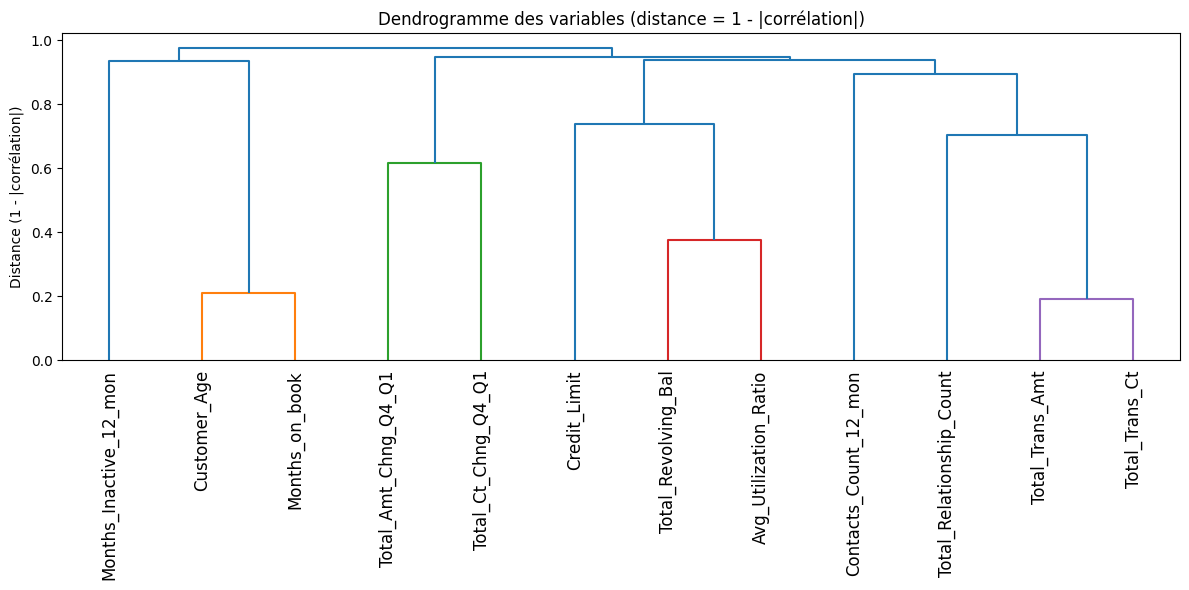

Dendrogramme des variables sauvegardé : figures/dendrogramme_variables.png

Top 5 des paires de variables les plus corrélées (redondance) :
Total_Trans_Amt       Total_Trans_Ct           0.807192
Customer_Age          Months_on_book           0.788912
Total_Revolving_Bal   Avg_Utilization_Ratio    0.624022
Credit_Limit          Avg_Utilization_Ratio    0.482965
Total_Amt_Chng_Q4_Q1  Total_Ct_Chng_Q4_Q1      0.384189
dtype: float64


In [3]:
print("=" * 60)
print("ÉTAPE 2 — CAH SUR LES VARIABLES")
print("=" * 60)

corr = X_scaled_df.corr()
dist_vars = 1 - corr.abs()
condensed_vars = squareform(dist_vars.values, checks=False)
Z_vars = linkage(condensed_vars, method="average")

plt.figure(figsize=(12, 6))
dendrogram(Z_vars, labels=corr.columns.tolist(), leaf_rotation=90)
plt.title("Dendrogramme des variables (distance = 1 - |corrélation|)")
plt.ylabel("Distance (1 - |corrélation|)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/dendrogramme_variables.png", dpi=150)
plt.show()
print(f"Dendrogramme des variables sauvegardé : {FIGURES_DIR}/dendrogramme_variables.png")

# Paires les plus corrélées (fusion immédiate attendue)
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("\nTop 5 des paires de variables les plus corrélées (redondance) :")
print(corr_pairs.head(5))

## Étape 3 — ACP (PCA)

In [4]:
print("=" * 60)
print("ÉTAPE 3 — ACP (PCA)")
print("=" * 60)

N_COMPONENTS = 4
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("Variance expliquée par composante :")
for i, v in enumerate(explained, start=1):
    print(f"  PC{i} : {v * 100:.1f}%")
print(f"Variance cumulée (4 axes) : {explained.sum() * 100:.1f}%")

loadings = pd.DataFrame(
    pca.components_.T,
    index=behavior_features,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
)
print("\nContributions des variables aux axes (loadings) :")
print(loadings.round(2))

ÉTAPE 3 — ACP (PCA)
Variance expliquée par composante :
  PC1 : 17.7%
  PC2 : 15.3%
  PC3 : 14.8%
  PC4 : 11.3%
Variance cumulée (4 axes) : 59.0%

Contributions des variables aux axes (loadings) :
                           PC1   PC2   PC3   PC4
Customer_Age             -0.20 -0.31  0.59  0.09
Months_on_book           -0.19 -0.32  0.59  0.10
Total_Relationship_Count -0.33  0.13 -0.11  0.21
Months_Inactive_12_mon   -0.08 -0.09  0.05 -0.07
Contacts_Count_12_mon    -0.16 -0.09 -0.15 -0.06
Credit_Limit              0.20 -0.34 -0.11  0.21
Total_Revolving_Bal       0.02  0.46  0.31 -0.11
Total_Amt_Chng_Q4_Q1      0.08  0.21  0.01  0.65
Total_Trans_Amt           0.61 -0.05  0.17 -0.08
Total_Trans_Ct            0.58  0.01  0.18 -0.10
Total_Ct_Chng_Q4_Q1       0.13  0.22  0.10  0.62
Avg_Utilization_Ratio    -0.12  0.59  0.31 -0.23


## Étape 4 — CAH sur les individus (le cœur)

ÉTAPE 4 — CAH SUR LES INDIVIDUS (Ward, sur composantes PCA)


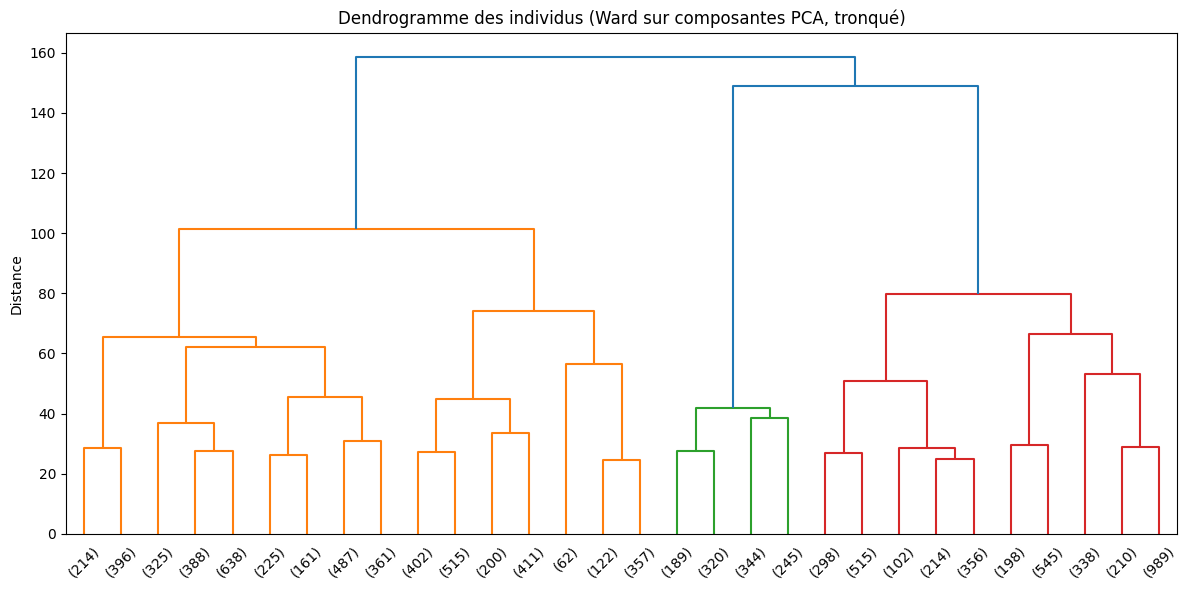

Dendrogramme des individus sauvegardé : figures/dendrogramme_individus.png

Plus grand saut de distance détecté → k = 3 segments retenus


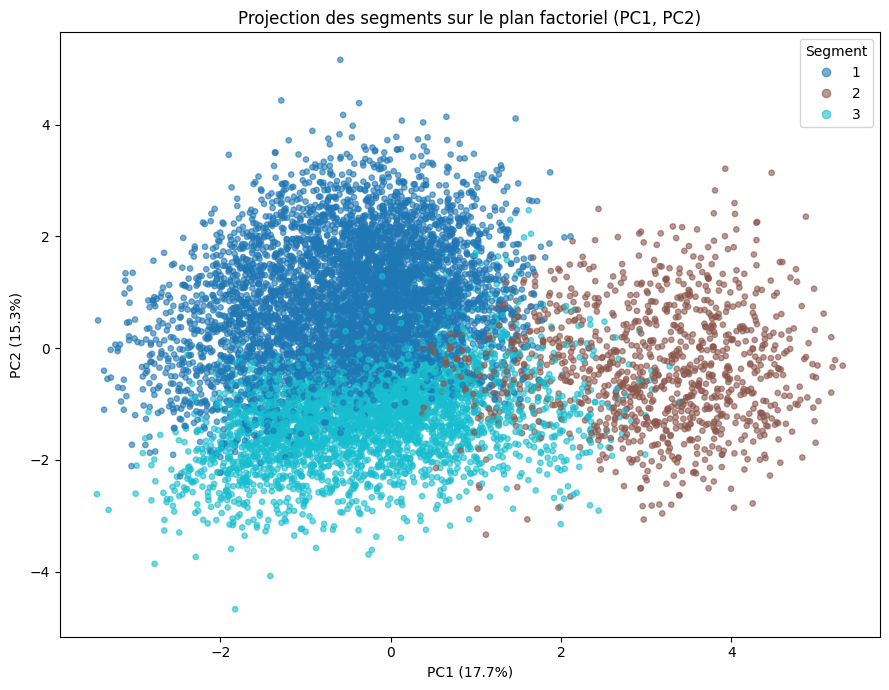

Projection des segments sauvegardée : figures/plan_factoriel_segments.png


In [5]:
print("=" * 60)
print("ÉTAPE 4 — CAH SUR LES INDIVIDUS (Ward, sur composantes PCA)")
print("=" * 60)

Z_ind = linkage(X_pca, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z_ind, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Dendrogramme des individus (Ward sur composantes PCA, tronqué)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/dendrogramme_individus.png", dpi=150)
plt.show()
print(f"Dendrogramme des individus sauvegardé : {FIGURES_DIR}/dendrogramme_individus.png")

# Choix du nombre de clusters : plus grand saut de distance dans les dernières fusions.
# last_merges[i] est la distance de fusion qui laisse (len(last_merges) - i) clusters.
# Le plus grand saut jumps[i] = last_merges[i+1] - last_merges[i] indique qu'il ne faut
# PAS effectuer la fusion i+1 : on s'arrête donc à (len(last_merges) - argmax(jumps)) clusters.
last_merges = Z_ind[-10:, 2]
jumps = np.diff(last_merges)
n_clusters = len(last_merges) - np.argmax(jumps)
n_clusters = max(2, min(6, n_clusters))
print(f"\nPlus grand saut de distance détecté → k = {n_clusters} segments retenus")

df_sample["Segment"] = fcluster(Z_ind, t=n_clusters, criterion="maxclust")

# Validation visuelle : projection des clusters sur le plan factoriel PC1-PC2
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_sample["Segment"], cmap="tab10", alpha=0.6, s=15
)
plt.xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1] * 100:.1f}%)")
plt.title("Projection des segments sur le plan factoriel (PC1, PC2)")
plt.legend(*scatter.legend_elements(), title="Segment")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/plan_factoriel_segments.png", dpi=150)
plt.show()
print(f"Projection des segments sauvegardée : {FIGURES_DIR}/plan_factoriel_segments.png")

## Étape 5 — Profilage des segments et croisement au churn

In [6]:
print("=" * 60)
print("ÉTAPE 5 — PROFILAGE DES SEGMENTS ET CROISEMENT AU CHURN")
print("=" * 60)

df_sample["Churn"] = (df_sample["Attrition_Flag"] == "Attrited Customer").astype(int)

# Moyennes des variables clés par segment
profile_means = df_sample.groupby("Segment")[behavior_features].mean().round(1)
print("\nProfil moyen (variables clés) par segment :")
print(profile_means)

# Composition démographique par segment
demographic_cols = ["Gender", "Income_Category", "Card_Category", "Education_Level"]
print("\nComposition démographique dominante par segment :")
for col in demographic_cols:
    dominant = df_sample.groupby("Segment")[col].agg(lambda s: s.value_counts().idxmax())
    print(f"  {col} (modalité dominante) :\n{dominant.to_string()}\n")

# Taux de churn et taille par segment — la table qui porte le projet
segment_size = df_sample.groupby("Segment").size().rename("Nb_clients")
segment_churn = (df_sample.groupby("Segment")["Churn"].mean() * 100).round(1).rename("Taux_churn_%")

resultats = pd.concat([segment_size, segment_churn, profile_means], axis=1)
resultats = resultats.sort_values("Taux_churn_%", ascending=False)

print("\n" + "=" * 60)
print("TABLE FINALE — SEGMENTS x TAUX DE CHURN")
print("=" * 60)
print(resultats)

resultats.to_csv(f"{DATA_DIR}/segments_churn_resultats.csv")
print(f"\nTable exportée : {DATA_DIR}/segments_churn_resultats.csv")

ÉTAPE 5 — PROFILAGE DES SEGMENTS ET CROISEMENT AU CHURN

Profil moyen (variables clés) par segment :
         Customer_Age  Months_on_book  Total_Relationship_Count  \
Segment                                                           
1                46.7            36.2                       4.2   
2                45.5            35.3                       2.1   
3                46.1            35.7                       3.8   

         Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
Segment                                                                
1                           2.3                    2.4        5105.2   
2                           2.2                    2.1       13739.5   
3                           2.4                    2.6       12073.4   

         Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  \
Segment                                                               
1                     1612.1                   0.8          

## Étape 6 — KNN : prédiction supervisée du churn


ÉTAPE 6 — KNN : PRÉDICTION SUPERVISÉE DU CHURN
Train : 7595 clients | Test : 2532 clients
Taux de churn train : 16.1% | test : 16.1%



Meilleurs paramètres (CV, score F1) : {'n_neighbors': 5, 'weights': 'distance'}
Score F1 en validation croisée : 0.743



Accuracy (test) : 0.925
F1-score churn (test) : 0.742

Rapport de classification :
              precision    recall  f1-score   support

   Non-churn       0.94      0.97      0.96      2125
       Churn       0.83      0.67      0.74       407

    accuracy                           0.92      2532
   macro avg       0.88      0.82      0.85      2532
weighted avg       0.92      0.92      0.92      2532

Matrice de confusion :
[[2067   58]
 [ 133  274]]


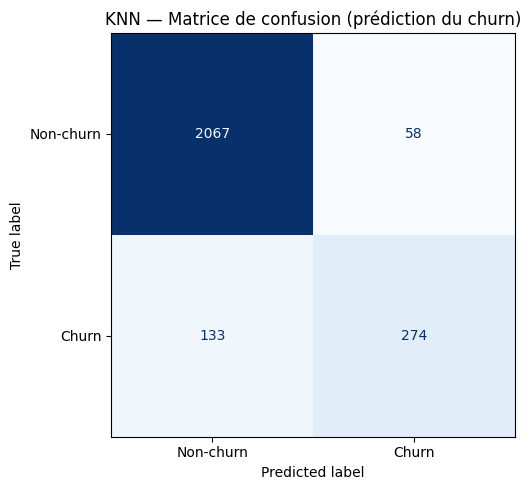

Matrice de confusion sauvegardée : figures/knn_confusion_matrix.png


In [7]:
print("\n" + "=" * 60)
print("ÉTAPE 6 — KNN : PRÉDICTION SUPERVISÉE DU CHURN")
print("=" * 60)

y = df_sample["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")
print(f"Taux de churn train : {y_train.mean() * 100:.1f}% | test : {y_test.mean() * 100:.1f}%")

# Recherche du meilleur k par validation croisée (F1, car classes déséquilibrées)
param_grid = {"n_neighbors": list(range(3, 26, 2)), "weights": ["uniform", "distance"]}
grid = GridSearchCV(
    KNeighborsClassifier(), param_grid, scoring="f1", cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"\nMeilleurs paramètres (CV, score F1) : {grid.best_params_}")
print(f"Score F1 en validation croisée : {grid.best_score_:.3f}")

knn = grid.best_estimator_
y_pred = knn.predict(X_test)

print(f"\nAccuracy (test) : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-score churn (test) : {f1_score(y_test, y_pred):.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Non-churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

# ConfusionMatrixDisplay.plot() crée sa propre figure via plt.subplots() quand ax=None :
# un plt.figure() préalable serait ignoré (figure vide en trop). On passe donc ax=
# explicitement pour que figsize=(6, 5) soit réellement appliqué.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Non-churn", "Churn"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("KNN — Matrice de confusion (prédiction du churn)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/knn_confusion_matrix.png", dpi=150)
plt.show()
print(f"Matrice de confusion sauvegardée : {FIGURES_DIR}/knn_confusion_matrix.png")

## Étape 7 — Clustering K-Means par profil dépensier

Segmentation complémentaire, indépendante des segments comportementaux de l'étape 4, basée uniquement sur les variables de dépense et d'utilisation du crédit. Objectif : faire ressortir des profils dépensiers (petit utilisateur, gros dépensier, dépense en hausse/baisse, etc.) et les croiser avec le churn.

In [8]:
print("=" * 60)
print("ÉTAPE 7 — PROFIL DÉPENSIER : PETIT / MOYEN / GRAND (K-MEANS, k=3)")
print("=" * 60)

# Profil dépensier = volume de dépense pur (montant total + nombre de transactions).
# On exclut volontairement Total_Revolving_Bal / Avg_Utilization_Ratio : ce sont des
# variables d'endettement/utilisation du crédit (pas de dépense), et Avg_Utilization_Ratio
# est de toute façon une fonction directe de Total_Revolving_Bal / Credit_Limit (corr = 1.0),
# ce qui réintroduirait indirectement l'axe "plafond de crédit" déjà traité aux étapes 1-4.
# En se limitant au volume de dépense, k=3 donne une séparation nette (silhouette = 0.61,
# contre 0.27 en mélangeant avec l'endettement) — cohérent avec l'objectif petit/moyen/grand.
spend_volume_features = ["Total_Trans_Amt", "Total_Trans_Ct"]
X_spend = X_scaled_df[spend_volume_features].values

k_spend = 3
kmeans_final = KMeans(n_clusters=k_spend, random_state=RANDOM_STATE, n_init=10)
raw_labels = kmeans_final.fit_predict(X_spend)
print(f"Silhouette (k={k_spend}) : {silhouette_score(X_spend, raw_labels):.3f}")

# Les identifiants bruts de KMeans (0/1/2) sont arbitraires : on les reclasse par montant
# moyen dépensé pour obtenir un vrai classement petit → grand dépensier.
order = (
    pd.Series(raw_labels, name="_tmp")
    .to_frame()
    .assign(Total_Trans_Amt=df_sample["Total_Trans_Amt"].values)
    .groupby("_tmp")["Total_Trans_Amt"]
    .mean()
    .sort_values()
    .index
)
profil_labels = ["Petit dépensier", "Moyen dépensier", "Grand dépensier"]
label_map = dict(zip(order, profil_labels))
df_sample["Profil_Depensier"] = pd.Categorical(
    [label_map[c] for c in raw_labels], categories=profil_labels, ordered=True
)
print("\nRépartition :")
print(df_sample["Profil_Depensier"].value_counts().reindex(profil_labels))

ÉTAPE 7 — PROFIL DÉPENSIER : PETIT / MOYEN / GRAND (K-MEANS, k=3)


Silhouette (k=3) : 0.611

Répartition :
Profil_Depensier
Petit dépensier    3806
Moyen dépensier    5545
Grand dépensier     776
Name: count, dtype: int64



Profil moyen par profil dépensier :
                  Total_Trans_Amt  Total_Trans_Ct  Total_Revolving_Bal  \
Profil_Depensier                                                         
Petit dépensier            1943.4            40.1               1138.7   
Moyen dépensier            4682.3            75.5               1150.2   
Grand dépensier           14484.9           110.2               1371.6   

                  Avg_Utilization_Ratio  
Profil_Depensier                         
Petit dépensier                     0.3  
Moyen dépensier                     0.3  
Grand dépensier                     0.2  

TABLE — PROFIL DÉPENSIER (PETIT/MOYEN/GRAND) x TAUX DE CHURN
                  Nb_clients  Taux_churn_%  Total_Trans_Amt  Total_Trans_Ct  \
Profil_Depensier                                                              
Petit dépensier         3806          34.8           1943.4            40.1   
Moyen dépensier         5545           5.4           4682.3            75.5   
Gran

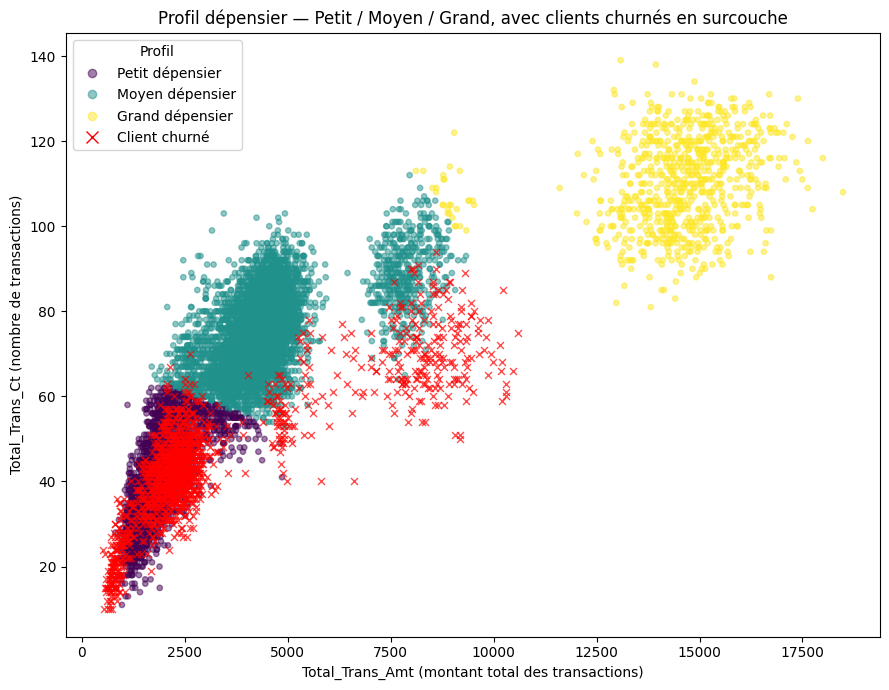

Visualisation sauvegardée : figures/kmeans_profil_depensier.png


In [9]:
# Profil moyen par profil dépensier
profile_view_cols = ["Total_Trans_Amt", "Total_Trans_Ct", "Total_Revolving_Bal", "Avg_Utilization_Ratio"]
spend_profile_means = df_sample.groupby("Profil_Depensier", observed=True)[profile_view_cols].mean().round(1)
print("\nProfil moyen par profil dépensier :")
print(spend_profile_means)

# Taille et taux de churn par profil dépensier
spend_size = df_sample.groupby("Profil_Depensier", observed=True).size().rename("Nb_clients")
spend_churn = (df_sample.groupby("Profil_Depensier", observed=True)["Churn"].mean() * 100).round(1).rename("Taux_churn_%")

resultats_kmeans = pd.concat([spend_size, spend_churn, spend_profile_means], axis=1)

print("\n" + "=" * 60)
print("TABLE — PROFIL DÉPENSIER (PETIT/MOYEN/GRAND) x TAUX DE CHURN")
print("=" * 60)
print(resultats_kmeans)

resultats_kmeans.to_csv(f"{DATA_DIR}/kmeans_profil_depensier_resultats.csv")
print(f"\nTable exportée : {DATA_DIR}/kmeans_profil_depensier_resultats.csv")

# Visualisation : montant total des transactions vs nombre de transactions, coloré par profil,
# avec surcouche des clients churnés (x rouge) pour voir où ils se concentrent réellement.
non_churn = df_sample[df_sample["Churn"] == 0]
churn = df_sample[df_sample["Churn"] == 1]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    non_churn["Total_Trans_Amt"],
    non_churn["Total_Trans_Ct"],
    c=non_churn["Profil_Depensier"].cat.codes,
    cmap="viridis",
    alpha=0.5,
    s=15,
)
plt.scatter(
    churn["Total_Trans_Amt"],
    churn["Total_Trans_Ct"],
    c="red",
    marker="x",
    alpha=0.7,
    s=25,
    linewidths=1,
)
plt.xlabel("Total_Trans_Amt (montant total des transactions)")
plt.ylabel("Total_Trans_Ct (nombre de transactions)")
plt.title("Profil dépensier — Petit / Moyen / Grand, avec clients churnés en surcouche")
handles, _ = scatter.legend_elements()
churn_handle = plt.Line2D([0], [0], marker="x", color="red", linestyle="", markersize=8)
plt.legend(
    list(handles) + [churn_handle],
    ["Petit dépensier", "Moyen dépensier", "Grand dépensier", "Client churné"],
    title="Profil",
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/kmeans_profil_depensier.png", dpi=150)
plt.show()
print(f"Visualisation sauvegardée : {FIGURES_DIR}/kmeans_profil_depensier.png")